In [2]:
import pandas as pd

file_path = r"C:\Users\santo\Downloads\Telco_Customer_Churn_Dataset  (3).csv"

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


tenure categories

In [3]:
def tenure_category(tenure):
    if tenure <= 12:
        return "0-12 Months"
    elif tenure <= 36:
        return "13-36 Months"
    else:
        return "37+ Months"

df["tenure_category"] = df["tenure"].apply(tenure_category)

df[["tenure", "tenure_category"]].head(10)


,tenure,tenure_category
0,1,0-12 Months
1,34,13-36 Months
2,2,0-12 Months
3,45,37+ Months
4,2,0-12 Months
5,8,0-12 Months
6,22,13-36 Months
7,10,0-12 Months
8,28,13-36 Months
9,62,37+ Months


In [4]:
df["tenure_category"].value_counts()

tenure_category
37+ Months      3001
0-12 Months     2186
13-36 Months    1856
Name: count, dtype: int64

donut chart for tenure

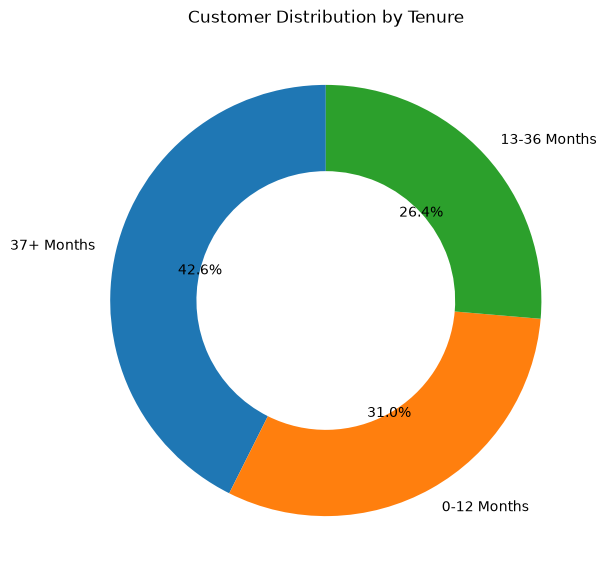

In [5]:
import matplotlib.pyplot as plt

tenure_counts = df["tenure_category"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    tenure_counts,
    labels=tenure_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Customer Distribution by Tenure")
plt.show()

Average Monthly Charges

In [8]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'tenure_category']

In [9]:
avg_charges = df.groupby("tenure_category")["MonthlyCharges"].mean()

print(avg_charges)

tenure_category
0-12 Months     56.097781
13-36 Months    63.248195
37+ Months      72.008730
Name: MonthlyCharges, dtype: float64


bar chart

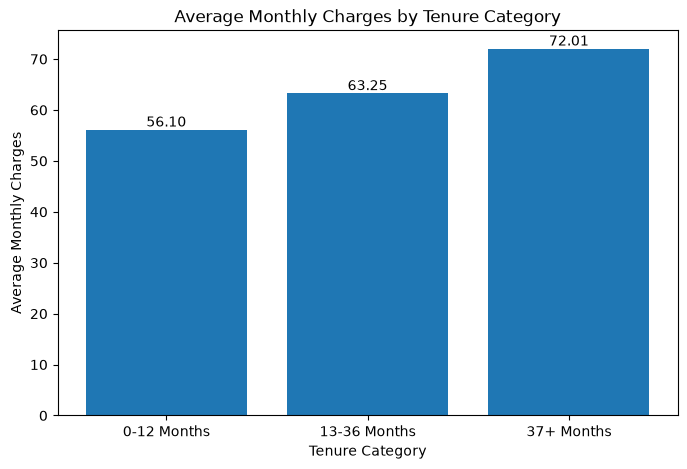

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

bars = plt.bar(
    avg_charges.index,
    avg_charges.values
)

plt.title("Average Monthly Charges by Tenure Category")
plt.xlabel("Tenure Category")
plt.ylabel("Average Monthly Charges")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.show()

Interactive bar chart with Plotly

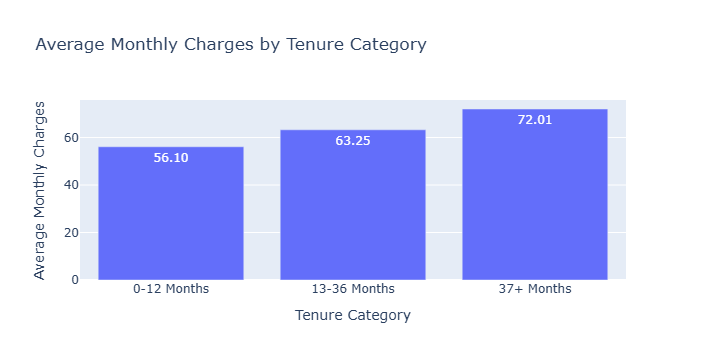

In [12]:
import plotly.express as px

avg_charges = (
    df.groupby("tenure_category", as_index=False)["MonthlyCharges"]
    .mean()
)

fig = px.bar(
    avg_charges,
    x="tenure_category",
    y="MonthlyCharges",
    title="Average Monthly Charges by Tenure Category",
    labels={
        "tenure_category": "Tenure Category",
        "MonthlyCharges": "Average Monthly Charges"
    },
    text_auto=".2f"
)

fig.show()
